In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
import tensorflow.keras as keras
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import (
    Dense,
    Activation,
    Flatten,
    Dropout,
    BatchNormalization,
    Conv2D,
    MaxPooling2D,
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import regularizers, optimizers
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import resnet
from tensorflow.keras import Model
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers.schedules import ExponentialDecay

from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import classification_report ,confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import pandas as pd

from collections import defaultdict

import PIL
import os
import cv2

In [3]:
# Định nghĩa đường dẫn và tên lớp
train_path = '/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/train'
valid_path = '/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/valid'
test_path = '/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/test'
CLASS_NAMES = ["adenocarcinoma", "large cell carcinoma", "normal", "squamous cell carcinoma"]


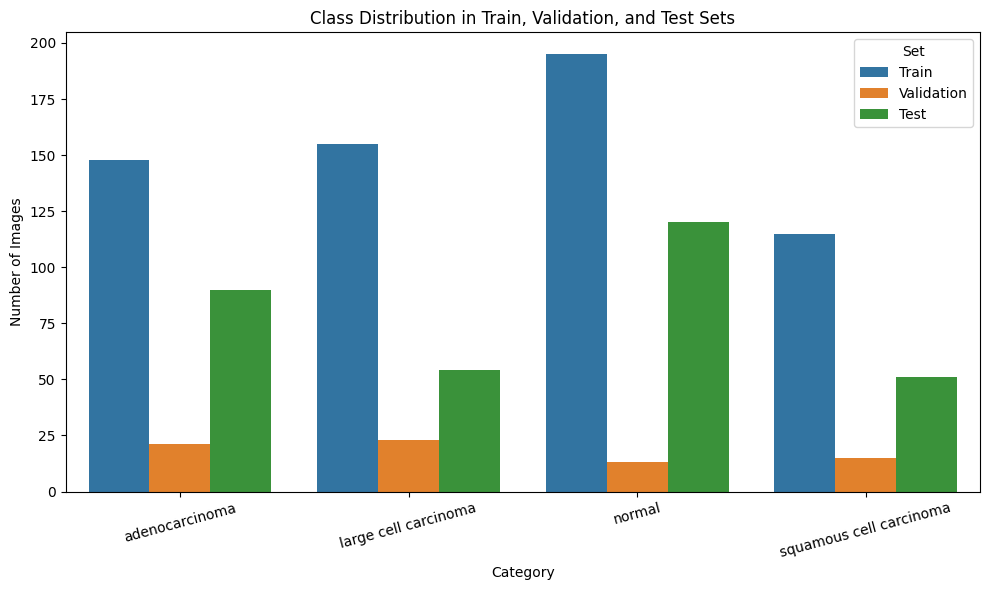

In [5]:
# Đếm và trực quan hóa số lượng ảnh theo lớp
def count_images_per_class(base_path):
    class_counts = {}
    for i, class_name in enumerate(os.listdir(base_path)):
        class_dir = os.path.join(base_path, class_name)
        if os.path.isdir(class_dir):
            num_images = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])
            class_counts[CLASS_NAMES[i]] = num_images
    return class_counts

datasets = {'Train': train_path, 'Validation': valid_path, 'Test': test_path}
all_counts = defaultdict(dict)

for name, path in datasets.items():
    counts = count_images_per_class(path)
    for cls, count in counts.items():
        all_counts[cls][name] = count

df = pd.DataFrame(all_counts).T.fillna(0).astype(int)
df = df.reset_index().rename(columns={'index': 'Category'})
df = pd.melt(df, id_vars="Category", var_name="Set", value_name="Count")

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Category", y="Count", hue="Set")
plt.title("Class Distribution in Train, Validation, and Test Sets")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


(282, 381, 3)


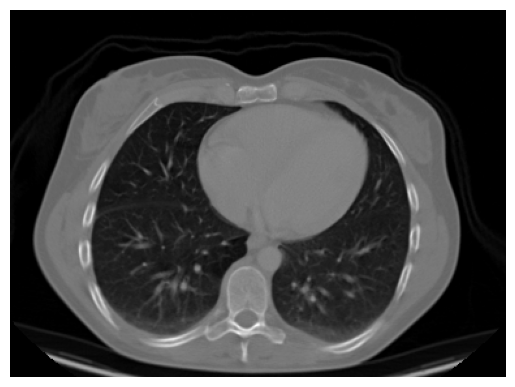

In [8]:
def view_image(image_path):
    image = mpimg.imread(image_path)[...,:3]
    print(image.shape)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

view_image("/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/test/adenocarcinoma/000108 (3).png")

In [9]:
# Chuẩn bị dữ liệu với ImageDataGenerator
image_shape = (224, 224, 3)
N_CLASSES = 4
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input, dtype="float32")
train_generator = train_datagen.flow_from_directory(train_path,
                                                    batch_size=BATCH_SIZE,
                                                    target_size=(image_shape[0], image_shape[0]),
                                                    class_mode="categorical")

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input, dtype="float32")
valid_generator = valid_datagen.flow_from_directory(valid_path,
                                                    batch_size=BATCH_SIZE,
                                                    target_size=(image_shape[0], image_shape[0]),
                                                    class_mode="categorical")

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input, dtype="float32")
test_generator = test_datagen.flow_from_directory(test_path,
                                                  batch_size=BATCH_SIZE,
                                                  target_size=(image_shape[0], image_shape[0]),
                                                  class_mode="categorical")


Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.


In [10]:
# Xây dựng mô hình ResNet50
res_model = ResNet50(include_top=False, pooling="avg", weights="imagenet", input_shape=image_shape)
for layer in res_model.layers:
    if "conv5" not in layer.name:
        layer.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [11]:
model = Sequential()
model.add(res_model)
model.add(Dropout(0.4))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(N_CLASSES, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,604,100 (90.04 MB)

 Trainable params: 14,988,292 (57.18 MB)

 Non-trainable params: 8,615,808 (32.87 MB)

In [14]:
# Cấu hình learning rate và biên dịch mô hình
lr_schedule = ExponentialDecay(initial_learning_rate=0.00001, decay_steps=100000, decay_rate=0.99995, staircase=True)
optimizer = optimizers.Adam(learning_rate=lr_schedule)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["acc"])

In [13]:
# Thiết lập callbacks
checkpointer = ModelCheckpoint(filepath="/content/chest-ct-scan-ResNet50.keras", monitor="val_loss", verbose=1, save_best_only=True)
early_stopping = EarlyStopping(verbose=1, patience=15)

In [15]:
# Huấn luyện mô hình
history = model.fit(train_generator,
                    steps_per_epoch=len(train_generator) // BATCH_SIZE,
                    epochs=100,
                    verbose=1,
                    validation_data=valid_generator,
                    callbacks=[checkpointer, early_stopping])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - acc: 0.3180 - loss: 2.0262 
Epoch 1: val_loss improved from inf to 1.66548, saving model to /content/chest-ct-scan-ResNet50.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 329s 15s/step - acc: 0.3193 - loss: 2.0216 - val_acc: 0.2917 - val_loss: 1.6655
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - acc: 0.3988 - loss: 1.6084
Epoch 2: val_loss improved from 1.66548 to 1.31446, saving model to /content/chest-ct-scan-ResNet50.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 425ms/step - acc: 0.4015 - loss: 1.5999 - val_acc: 0.3194 - val_loss: 1.3145
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - acc: 0.5389 - loss: 1.2091
Epoch 3: val_loss improved from 1.31446 to 1.08788, saving model to /content/chest-ct-scan-ResNet50.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 410ms/step - acc: 0.5393 - loss: 1.2061 - val_acc: 0.5000 - val_loss: 1.0879
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - acc: 0.6330 - loss: 0.9360
Epoch 4: val_loss improved from 1.0878

In [16]:
# Đánh giá mô hình trên tập test
result = model.evaluate(test_generator)
print(f"Test Loss: {result[0]}, Test Accuracy: {result[1]}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 117s 12s/step - acc: 0.7877 - loss: 0.7755
Test Loss: 0.6826695203781128, Test Accuracy: 0.8126984238624573


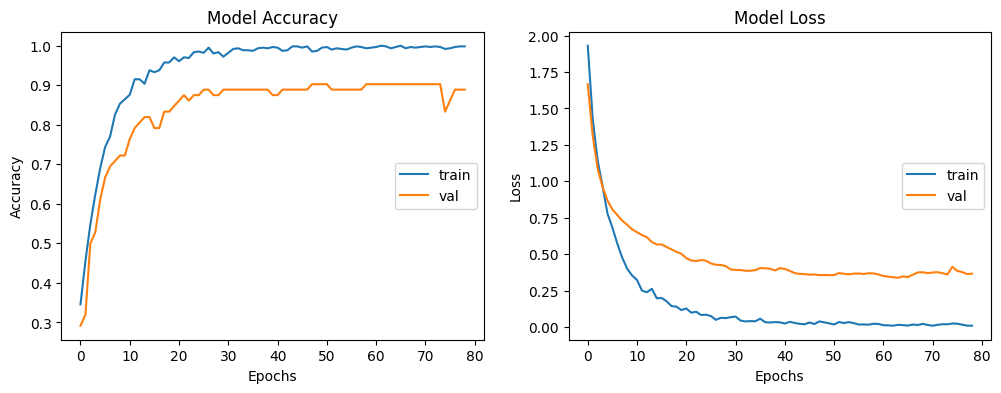

In [17]:
# Vẽ biểu đồ độ chính xác và hàm mất mát
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['acc'], label='train')
plt.plot(history.history['val_acc'], label='val')
plt.legend(loc='right')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(loc='right')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()

In [18]:
# Hàm tính toán dự đoán và ma trận nhầm lẫn
def get_preds_and_labels(generator, model):
    y_true = []
    y_pred = []
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        preds = model.predict(x_batch, verbose=0)
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))


Train Set:


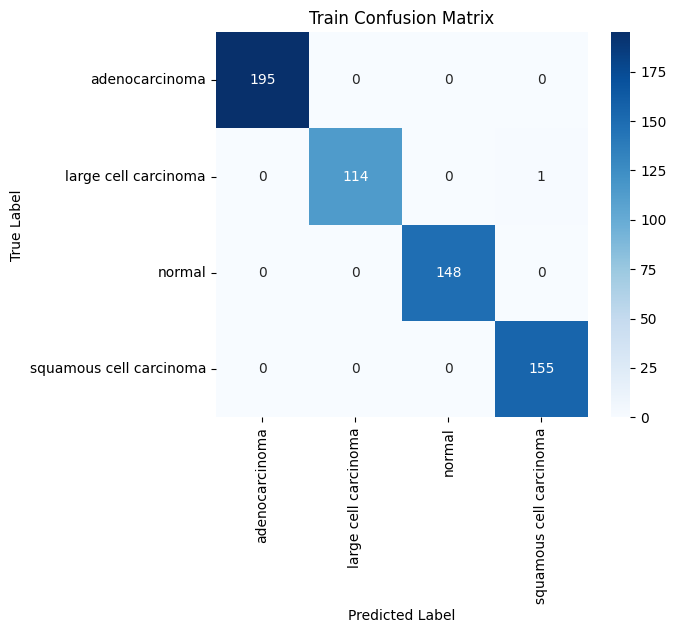


Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       1.00      1.00      1.00       195
   large cell carcinoma       1.00      0.99      1.00       115
                 normal       1.00      1.00      1.00       148
squamous cell carcinoma       0.99      1.00      1.00       155

               accuracy                           1.00       613
              macro avg       1.00      1.00      1.00       613
           weighted avg       1.00      1.00      1.00       613


Validation Set:


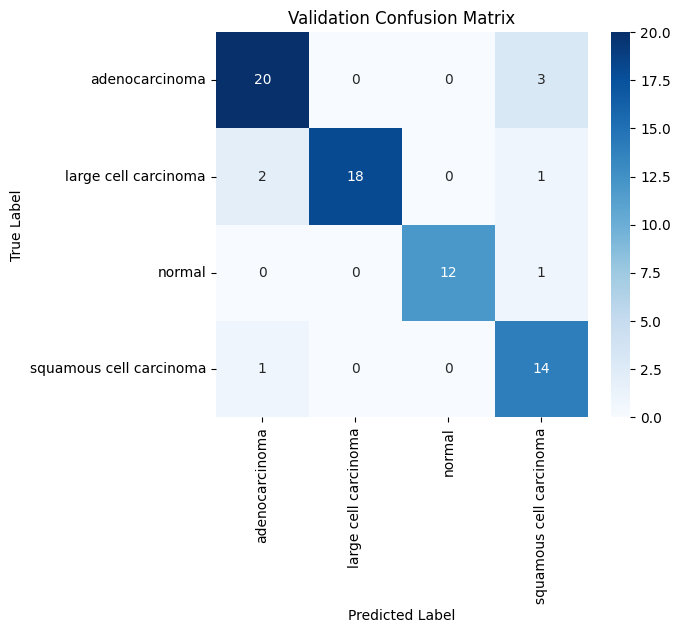


Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.87      0.87      0.87        23
   large cell carcinoma       1.00      0.86      0.92        21
                 normal       1.00      0.92      0.96        13
squamous cell carcinoma       0.74      0.93      0.82        15

               accuracy                           0.89        72
              macro avg       0.90      0.90      0.89        72
           weighted avg       0.90      0.89      0.89        72


Test Set:


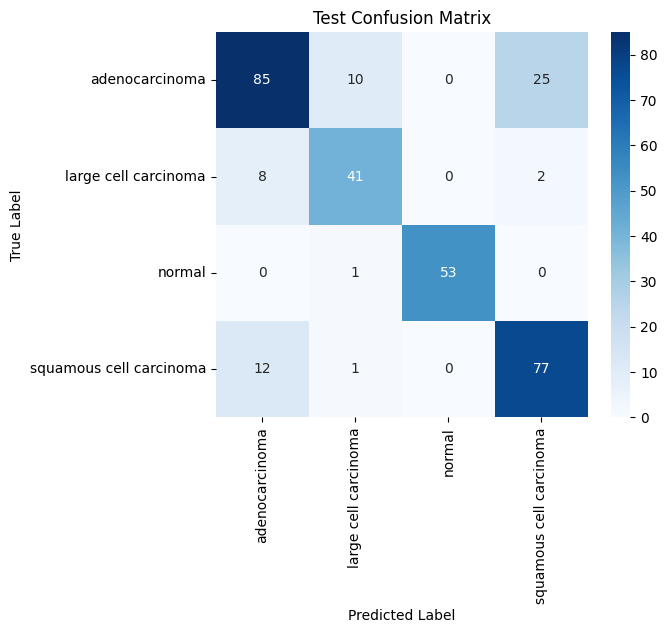


Classification Report:

                         precision    recall  f1-score   support

         adenocarcinoma       0.81      0.71      0.76       120
   large cell carcinoma       0.77      0.80      0.79        51
                 normal       1.00      0.98      0.99        54
squamous cell carcinoma       0.74      0.86      0.79        90

               accuracy                           0.81       315
              macro avg       0.83      0.84      0.83       315
           weighted avg       0.82      0.81      0.81       315



In [19]:
# Đánh giá trên các tập dữ liệu
for name, generator in [("Train", train_generator), ("Validation", valid_generator), ("Test", test_generator)]:
    print(f"\n{name} Set:")
    y_true, y_pred = get_preds_and_labels(generator, model)
    plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, f"{name} Confusion Matrix")